In [4]:
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from datetime import datetime
from scipy import stats
import seaborn as sns

In [5]:
eruptions = [
    "2025-03-20",
    "2025-04-22",
    "2025-05-18",
    "2025-06-17",
    "2025-07-07",
    "2025-08-01",
    "2025-08-17",
]

In [6]:
rsam_file = r"D:\Projects\magma-rsam\output\rsam\VG.OJN.00.EHN\not_filtered\combined_VG.OJN.00.EHN_2025-01-01-2025-08-24_not-filtered_10min.csv"

In [7]:
df = pd.read_csv(rsam_file, index_col=0, parse_dates=True)

In [8]:
df['mean_1d'] = df['mean'].rolling('1d').mean()
df['median_1d'] = df['median'].rolling('1d').median()

In [9]:
columns_to_plot = ['mean', 'median', 'mean_1d', 'median_1d']

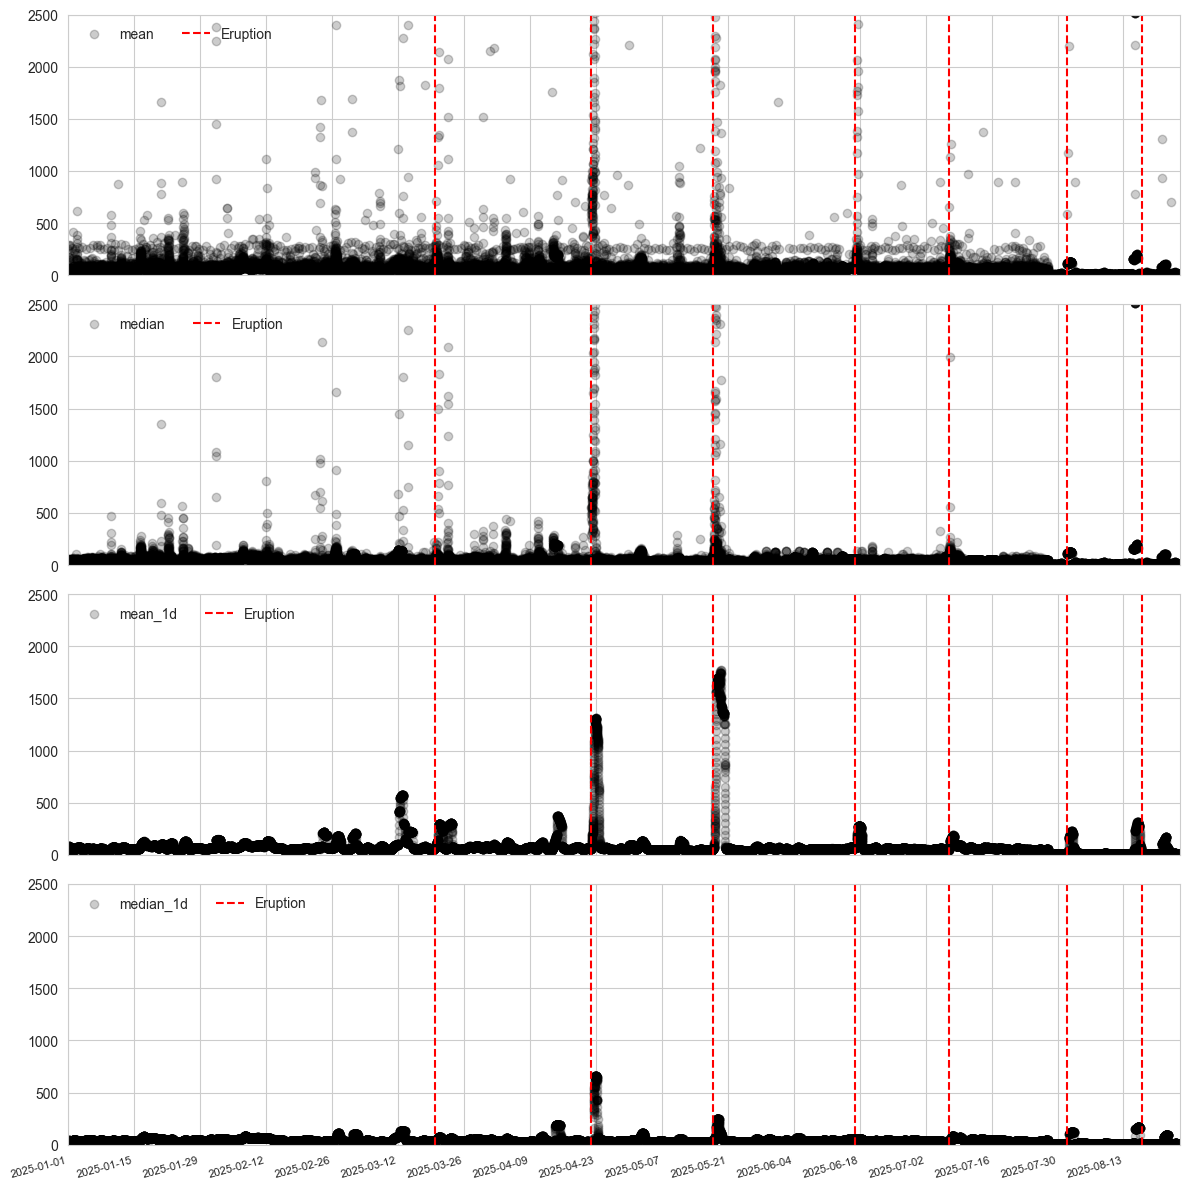

In [10]:
fig, axs = plt.subplots(nrows=len(columns_to_plot), ncols=1, sharex=True, sharey=True, figsize=(12, 3*len(columns_to_plot)))

for index, column in enumerate(columns_to_plot):
    ax = axs[index]
    ax.scatter(df.index, df[column], color='k', alpha=0.2, label=column)
    ax.set_xlim(df.index[0], df.index[-1])
    ax.set_ylim(0, 2500)
    for index, eruption in enumerate(eruptions):
        date_eruption = datetime.strptime(eruption, "%Y-%m-%d")
        ax.axvline(date_eruption, color='red', linestyle='--', label=f"Eruption" if index == 0 else "_")
    ax.legend(loc='upper left', ncol=3, fontsize=10, frameon=False)

    ax.xaxis.set_major_locator(mdates.DayLocator(interval=14))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    for label in ax.get_xticklabels(which="major"):
        label.set(rotation=15, horizontalalignment="right", fontsize=8)

plt.tight_layout()


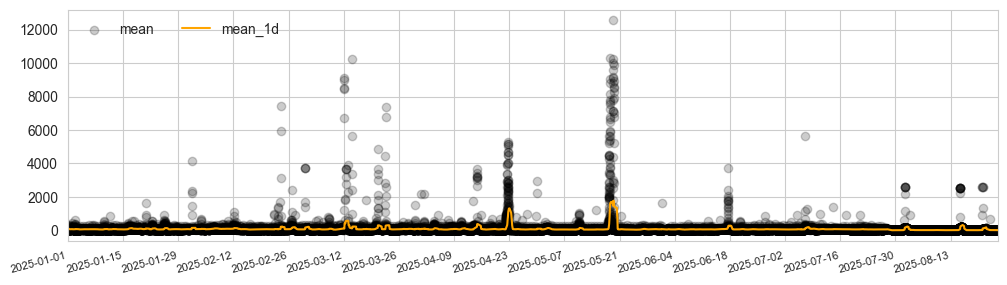

In [11]:
fig, ax = plt.subplots(nrows=1, ncols=1, sharex=True, sharey=True, figsize=(12, 3))

ax.scatter(df.index, df['mean'], color='k', alpha=0.2, label='mean')
ax.plot(df.index, df['mean_1d'], color='orange', label='mean_1d')

ax.legend(loc='upper left', ncol=3, fontsize=10, frameon=False)
ax.set_xlim(df.index[0], df.index[-1])
# ax.set_ylim(0, 2500)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=14))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
for label in ax.get_xticklabels(which="major"):
    label.set(rotation=15, horizontalalignment="right", fontsize=8)

<Axes: >

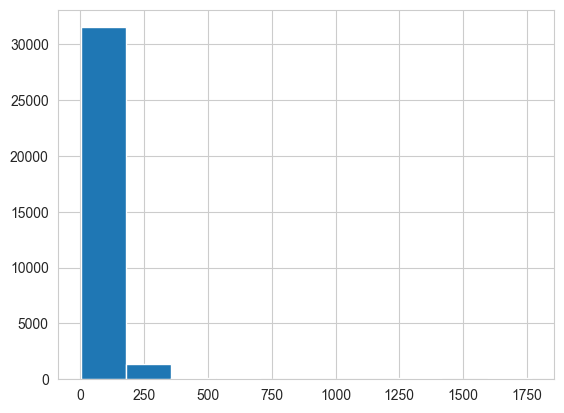

In [12]:
df['mean_1d'].hist(bins=10, label='mean')

In [13]:
df['distance_bin'] = pd.cut(df['mean'], bins=10)

In [14]:
df.groupby("distance_bin", observed=False).count()

,min,mean,max,median,std,mean_1d,median_1d
distance_bin,,,,,,,
"(-10.878, 1257.963]",33360,33360,33360,33360,33360,33360,33360
"(1257.963, 2514.243]",87,87,87,87,87,87,87
"(2514.243, 3770.522]",61,61,61,61,61,61,61
"(3770.522, 5026.801]",21,21,21,21,21,21,21
"(5026.801, 6283.08]",14,14,14,14,14,14,14
"(6283.08, 7539.359]",13,13,13,13,13,13,13
"(7539.359, 8795.638]",10,10,10,10,10,10,10
"(8795.638, 10051.917]",11,11,11,11,11,11,11
"(10051.917, 11308.196]",3,3,3,3,3,3,3


In [15]:
df['mean_1d_z_score'] = stats.zscore(df['mean_1d'])

In [16]:
df

,min,mean,max,median,std,mean_1d,median_1d,distance_bin,mean_1d_z_score
datetime,,,,,,,,,
2025-01-01 00:00:00,0.262505,28.494769,170.262505,24.262505,21.291337,28.494769,24.262505,"(-10.878, 1257.963]",-0.372440
2025-01-01 00:10:00,0.262505,28.476049,202.737495,24.262505,21.307754,28.485409,24.262505,"(-10.878, 1257.963]",-0.372498
2025-01-01 00:20:00,0.262505,27.628783,242.737495,23.262505,21.520434,28.199867,24.262505,"(-10.878, 1257.963]",-0.374283
2025-01-01 00:30:00,0.262505,26.719773,190.737495,22.737495,19.836367,27.829843,23.762505,"(-10.878, 1257.963]",-0.376597
2025-01-01 00:40:00,0.262505,29.868076,227.262505,25.262505,23.093513,28.237490,24.262505,"(-10.878, 1257.963]",-0.374048
...,...,...,...,...,...,...,...,...,...
2025-08-24 23:10:00,0.316436,3.991865,12.316436,3.316436,2.508546,7.750957,7.316436,"(-10.878, 1257.963]",-0.502123
2025-08-24 23:20:00,0.316436,3.440068,11.316436,3.316436,2.277529,7.611130,7.316436,"(-10.878, 1257.963]",-0.502998
2025-08-24 23:30:00,0.316436,3.169492,11.316436,2.683564,2.114544,7.494060,7.000000,"(-10.878, 1257.963]",-0.503729


In [30]:
df['mean_1d_z_score'].std()

np.float64(1.0000148897045145)

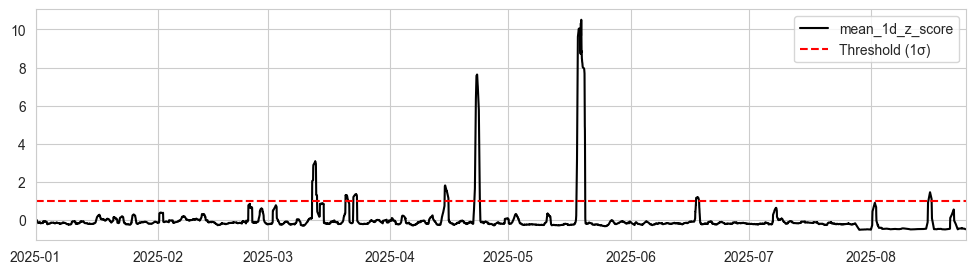

In [36]:
fig, ax = plt.subplots(1, 1, figsize=(12, 3))
ax.plot(df.index, df['mean_1d_z_score'], color='k', label='mean_1d_z_score')
ax.axhline(y=1, color='r', linestyle='--', label='Threshold (1σ)')
ax.set_xlim(df.index[0], df.index[-1])
ax.legend()

<Axes: ylabel='Density'>

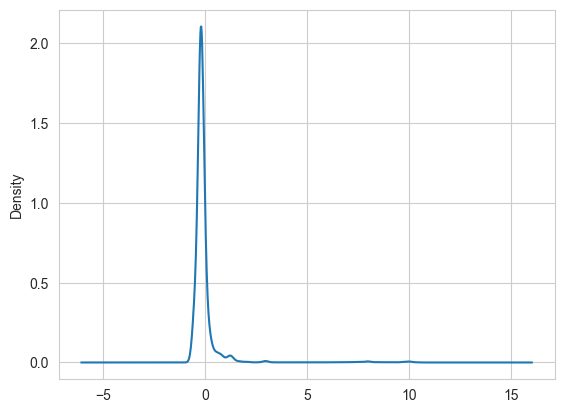

In [39]:
df['mean_1d_z_score'].plot.kde()